C:\Users\drtpr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\drtpr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Inertia (Sum of squared distances of samples to their closest cluster center): 78.85144142614601
Silhouette Score: 0.5528190123564095


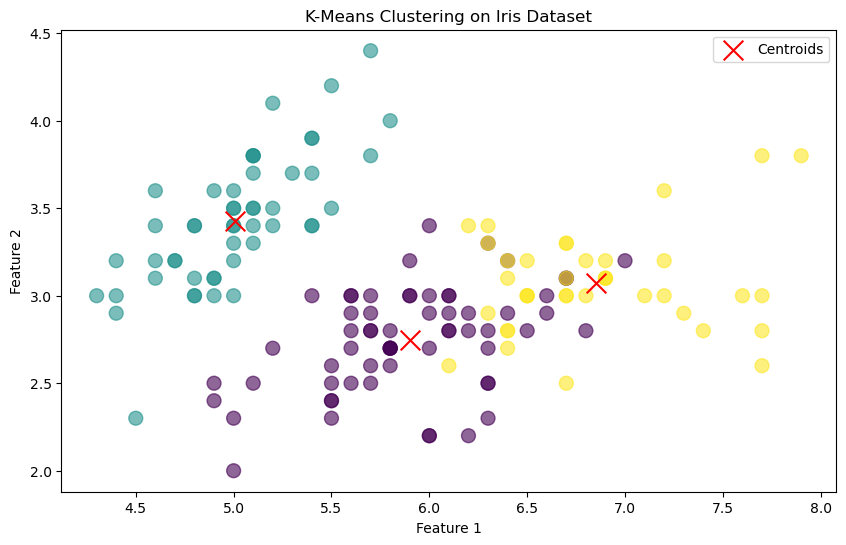

C:\Users\drtpr\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


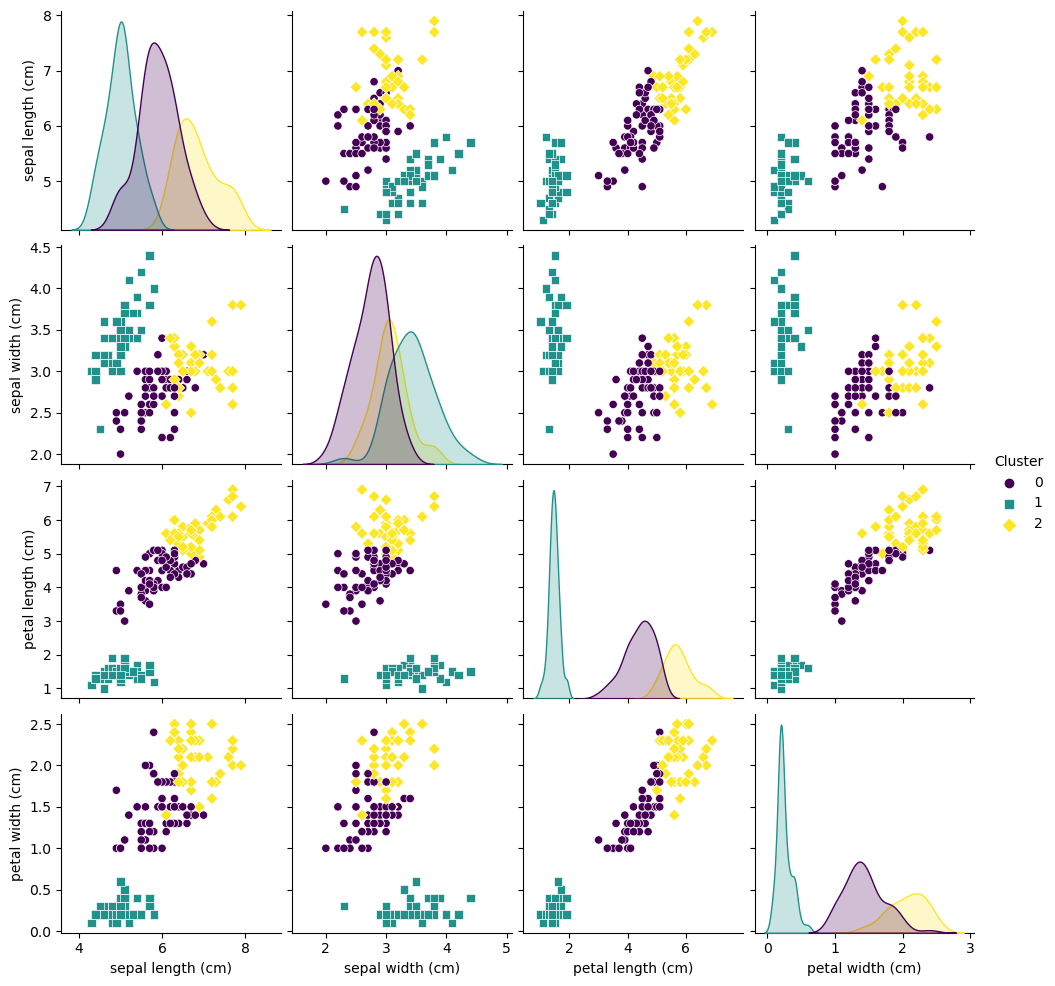

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Feature matrix
y = iris.target  # True labels (for evaluation purposes)

# Step 3: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # 3 clusters (since Iris has 3 classes)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Step 4: Evaluate the clustering performance

# 4.1: Inertia (within-cluster sum of squares)
print(f'Inertia (Sum of squared distances of samples to their closest cluster center): {kmeans.inertia_}')

# 4.2: Silhouette Score
sil_score = silhouette_score(X, y_kmeans)
print(f'Silhouette Score: {sil_score}')

# Step 5: Visualization
# Plotting the clusters
plt.figure(figsize=(10, 6))

# 2D projection of the first two features for simplicity
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', marker='o', s=100, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200, label='Centroids')
plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# Optional: Using Seaborn Pairplot to visualize clustering
df = pd.DataFrame(X, columns=iris.feature_names)
df['Cluster'] = y_kmeans
sns.pairplot(df, hue='Cluster', palette='viridis', markers=["o", "s", "D"])
plt.show()
